# Phần 1: Tải dữ liệu từ Kaggle
Sử dụng thư viện `kagglehub` để tải trực tiếp bộ dữ liệu **Telco Customer Churn** từ Kaggle vào môi trường Google Colab.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


# Phần 2: Data Ingestion & Preprocessing
Quá trình này bao gồm các bước làm sạch dữ liệu cốt lõi:
1. **Xử lý bẫy dữ liệu:** Cột `TotalCharges` chứa các khoảng trắng ẩn thay vì giá trị `NaN`.
2. **Loại bỏ nhiễu:** Xóa cột `customerID` không mang giá trị học máy.
3. **Feature Encoding:** Mã hóa các biến phân loại (Categorical) sang dạng số (One-Hot Encoding) để đưa vào mô hình.

In [2]:
import os
import pandas as pd
import numpy as np

# ==========================================
# 1. DATA INGESTION (Đọc dữ liệu từ thư mục Kagglehub)
# ==========================================
# Tìm file CSV trong thư mục path tải về
files = os.listdir(path)
csv_filename = [f for f in files if f.endswith('.csv')][0]
full_file_path = os.path.join(path, csv_filename)

# Đọc file vào Pandas DataFrame
df = pd.read_csv(full_file_path)
print(f"Đã load thành công dataset với {df.shape[0]} dòng và {df.shape[1]} cột.\n")

# ==========================================
# 2. PREPROCESSING (Tiền xử lý dữ liệu)
# ==========================================
# A. Xử lý "Bẫy dữ liệu" tại cột TotalCharges
# Cột này có một số dòng bị khoảng trắng ' ' thay vì giá trị NaN. Ta ép kiểu sang số thực.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Xóa các dòng bị lỗi (chỉ khoảng 11 dòng, rất an toàn để xóa)
df.dropna(subset=['TotalCharges'], inplace=True)

# B. Xóa các cột không có giá trị phân tích
# customerID là chuỗi định danh ngẫu nhiên, để lại sẽ làm nhiễu mô hình
df.drop('customerID', axis=1, inplace=True)

# C. Chuyển đổi Target (Cột Churn) sang dạng số
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# D. Encode Categorical Features (Mã hóa các biến phân loại)
# Chuyển đổi các cột dạng text (Gender, InternetService...) thành dạng số (One-Hot Encoding)
# Dùng drop_first=True để tránh bẫy đa cộng tuyến (Dummy Variable Trap)
df_encoded = pd.get_dummies(df, drop_first=True)

print("Kích thước dữ liệu sau khi Preprocessing:", df_encoded.shape)
print("Dữ liệu sẵn sàng cho Phần 3!")

Đã load thành công dataset với 7043 dòng và 21 cột.

Kích thước dữ liệu sau khi Preprocessing: (7032, 31)
Dữ liệu sẵn sàng cho Phần 3!


# Phần 3: Feature Engineering & Model Training
Tiến hành phân chia dữ liệu Train/Test và huấn luyện 2 mô hình phân loại:
* **Logistic Regression:** Áp dụng StandardScaler để chuẩn hóa dữ liệu và dùng tham số `class_weight='balanced'` để xử lý mất cân bằng.
* **XGBoost:** Loại bỏ các ký tự đặc biệt ở tên cột và dùng tham số `scale_pos_weight` để phạt nặng hơn nếu mô hình đoán sai nhóm khách hàng rời mạng.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# ==========================================
# 1. FEATURE ENGINEERING & SPLIT DATA
# ==========================================
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Stratify=y để giữ nguyên tỷ lệ mất cân bằng ở cả Train và Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling cho Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 2. TRAINING MÔ HÌNH: LOGISTIC REGRESSION
# ==========================================
print("=== KẾT QUẢ: LOGISTIC REGRESSION ===")
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
print(classification_report(y_test, y_pred_log))

# ==========================================
# 3. TRAINING MÔ HÌNH: XGBOOST
# ==========================================
print("\n=== KẾT QUẢ: XGBOOST ===")
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

# Đã SỬA CẢNH BÁO: Thêm chữ 'r' trước chuỗi regex (raw string)
X_train_xgb.columns = X_train_xgb.columns.str.replace(r'[<,>,\s]', '_', regex=True)
X_test_xgb.columns = X_test_xgb.columns.str.replace(r'[<,>,\s]', '_', regex=True)

# Tính tỷ lệ mất cân bằng cho XGBoost
scale_pos_weight_value = (len(y_train) - sum(y_train)) / sum(y_train)

# Đã SỬA CẢNH BÁO: Bỏ tham số use_label_encoder
xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight_value,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train_xgb, y_train)

y_pred_xgb = xgb_model.predict(X_test_xgb)
print(classification_report(y_test, y_pred_xgb))

=== KẾT QUẢ: LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407


=== KẾT QUẢ: XGBOOST ===
              precision    recall  f1-score   support

           0       0.87      0.78      0.82      1033
           1       0.53      0.68      0.60       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.75      0.76      1407



# Phần 4: Hyperparameter Tuning & Data Visualization
Thay vì dùng tham số mặc định, ta sẽ dùng **RandomizedSearchCV** để dò tìm bộ siêu tham số (hyperparameters) tối ưu nhất cho XGBoost, giúp cân bằng giữa Accuracy và Recall.

Sau khi train xong, ta sẽ trực quan hóa (Visualize) 2 biểu đồ quan trọng nhất:
1. **Feature Importance (Mức độ quan trọng của đặc trưng):** Xem yếu tố nào (Giá cước, Hợp đồng, Thời gian sử dụng...) quyết định việc khách hàng rời mạng.
2. **ROC-AUC Curve:** Đánh giá khả năng phân loại của mô hình một cách trực quan.

Đang tìm kiếm tham số tối ưu cho XGBoost (Quá trình này mất khoảng 1-2 phút)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Tham số tốt nhất: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.01}

=== KẾT QUẢ XGBOOST SAU KHI TUNING ===
              precision    recall  f1-score   support

           0       0.92      0.69      0.79      1033
           1       0.49      0.83      0.62       374

    accuracy                           0.73      1407
   macro avg       0.70      0.76      0.70      1407
weighted avg       0.80      0.73      0.74      1407



/tmp/ipykernel_8355/2169542244.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[features[i] for i in indices], ax=axes[0], palette="viridis")


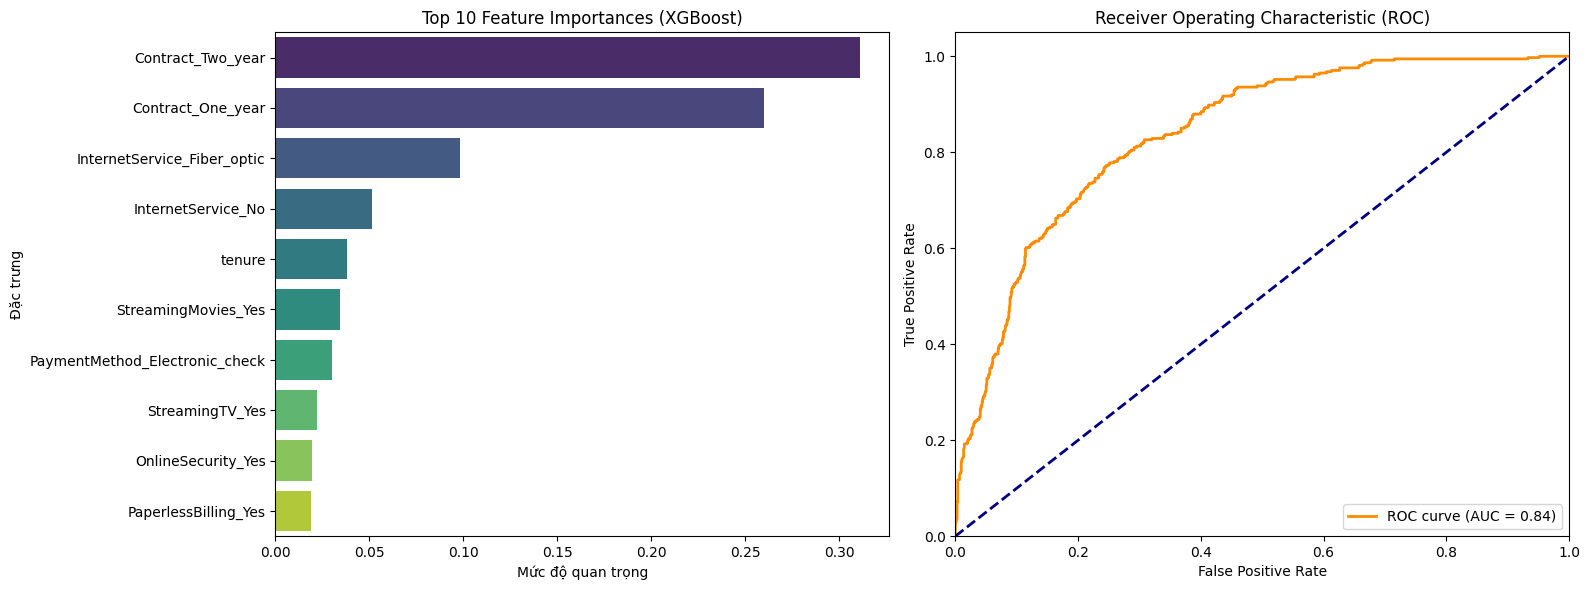

In [4]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from xgboost import XGBClassifier

print("Đang tìm kiếm tham số tối ưu cho XGBoost (Quá trình này mất khoảng 1-2 phút)...")

# 1. Khai báo không gian tham số cần tìm
param_dist = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 0.9, 1.0]
}

# 2. Khởi tạo mô hình cơ sở
# Nhắc lại: scale_pos_weight_value tính từ Phần 3 để xử lý mất cân bằng dữ liệu
xgb_base = XGBClassifier(scale_pos_weight=scale_pos_weight_value, eval_metric='logloss', random_state=42)

# 3. Chạy Randomized Search (Dùng Random thay vì Grid để tiết kiệm thời gian)
random_search = RandomizedSearchCV(
    xgb_base, param_distributions=param_dist, n_iter=10,
    scoring='recall', # Tối ưu hóa cho Recall (Bắt đúng khách rời mạng)
    cv=3, verbose=1, random_state=42, n_jobs=-1
)

random_search.fit(X_train_xgb, y_train)

# Lấy mô hình tốt nhất
best_xgb_model = random_search.best_estimator_
print(f"\nTham số tốt nhất: {random_search.best_params_}")

# Đánh giá lại
y_pred_best = best_xgb_model.predict(X_test_xgb)
print("\n=== KẾT QUẢ XGBOOST SAU KHI TUNING ===")
print(classification_report(y_test, y_pred_best))

# ==========================================
# TRỰC QUAN HÓA DỮ LIỆU (VISUALIZATION)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Feature Importance (Top 10)
importances = best_xgb_model.feature_importances_
indices = np.argsort(importances)[::-1][:10] # Lấy top 10
features = X_train_xgb.columns

sns.barplot(x=importances[indices], y=[features[i] for i in indices], ax=axes[0], palette="viridis")
axes[0].set_title("Top 10 Feature Importances (XGBoost)")
axes[0].set_xlabel("Mức độ quan trọng")
axes[0].set_ylabel("Đặc trưng")

# Biểu đồ 2: ROC Curve
y_pred_prob = best_xgb_model.predict_proba(X_test_xgb)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC)')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# Phần 5: MLflow - Tracking Experiments & Artifacts
Trong dự án thực tế, bạn sẽ train hàng chục phiên bản model khác nhau. **MLflow** sinh ra để ghi log lại toàn bộ lịch sử đó: bạn đã dùng tham số nào? Độ chính xác bao nhiêu? Và lưu trữ luôn file model `.pkl` (Artifacts) để sẵn sàng đem đi deploy.

*(Lưu ý: Chạy lệnh `!pip install mlflow` trước nếu môi trường của bạn chưa có).*

In [5]:
!pip install -q mlflow

import mlflow
import mlflow.xgboost
from sklearn.metrics import recall_score, f1_score, accuracy_score

# Thiết lập tên Project/Experiment trong MLflow
experiment_name = "Telco_Churn_Prediction"
mlflow.set_experiment(experiment_name)

print("Bắt đầu ghi log vào MLflow...")

# Bắt đầu một phiên theo dõi (Run)
with mlflow.start_run(run_name="XGBoost_Tuned_Model"):
    # 1. Log các tham số (Parameters) tốt nhất từ bước Tuning
    mlflow.log_params(random_search.best_params_)

    # Tính toán Metrics
    accuracy = accuracy_score(y_test, y_pred_best)
    recall = recall_score(y_test, y_pred_best)
    f1 = f1_score(y_test, y_pred_best)

    # 2. Log các chỉ số đánh giá (Metrics)
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)

    # 3. Log bản thân Model (Artifacts)
    # MLflow sẽ tự động đóng gói model cùng với môi trường (conda/pip) cần thiết
    mlflow.xgboost.log_model(best_xgb_model, "xgboost_churn_model")

    run_id = mlflow.active_run().info.run_id
    print(f"Hoàn tất! Model đã được lưu với Run ID: {run_id}")
    print(f"Metrics đã log: Accuracy={accuracy:.2f}, Recall={recall:.2f}, F1={f1:.2f}")

# (Tùy chọn) Để xem giao diện UI của MLflow trên Colab, bạn có thể chạy dòng sau ở một ô code khác:
# !mlflow ui --port 5000 & npx localtunnel --port 5000

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 683.2 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207

2026/04/18 08:12:41 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/18 08:12:41 INFO mlflow.store.db.utils: Updating database tables
2026/04/18 08:12:44 INFO mlflow.tracking.fluent: Experiment with name 'Telco_Churn_Prediction' does not exist. Creating a new experiment.


Bắt đầu ghi log vào MLflow...


2026/04/18 08:12:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Hoàn tất! Model đã được lưu với Run ID: 715142aaf0dd4c67aeb075c685d05c85
Metrics đã log: Accuracy=0.73, Recall=0.83, F1=0.62


# Phần 6: Data Quality Tests & Model Validation Tests
Đây là bước phòng vệ trong MLOps.
* **Data Quality Test:** Đảm bảo dữ liệu đầu vào không bị lỗi (VD: không có null, số lượng cột đúng chuẩn) trước khi đưa vào inference.
* **Model Validation:** Đảm bảo model mới train đạt đủ tiêu chuẩn tối thiểu (ví dụ: Recall phải > 75%) thì mới cho phép lên Production. Nếu rớt Test này, pipeline sẽ báo lỗi (Fail CI/CD).

In [6]:
print("Đang chạy Validation Tests...\n")

# ==========================================
# 1. DATA QUALITY TESTS
# ==========================================
def test_data_quality(df_train, df_test):
    # Test 1: Không có giá trị Null trong tập train/test
    assert df_train.isnull().sum().sum() == 0, "LỖI: Dữ liệu Train chứa giá trị Null!"
    assert df_test.isnull().sum().sum() == 0, "LỖI: Dữ liệu Test chứa giá trị Null!"

    # Test 2: Định dạng (Shape) phải khớp nhau về số lượng features
    assert df_train.shape[1] == df_test.shape[1], "LỖI: Số lượng cột tập Train và Test không khớp!"

    print("✅ Data Quality Tests: PASSED")

# ==========================================
# 2. MODEL VALIDATION TESTS
# ==========================================
def test_model_performance(model, X_test, y_test):
    predictions = model.predict(X_test)
    recall = recall_score(y_test, predictions)

    # Đặt ngưỡng Baseline: Recall của mô hình tối thiểu phải đạt 75%
    THRESHOLD = 0.75

    # Nếu Recall < 0.75, dòng lệnh assert sẽ quăng lỗi chặn pipeline lại
    assert recall >= THRESHOLD, f"LỖI: Mô hình bị suy thoái! Recall = {recall:.2f} (dưới mức {THRESHOLD})"

    print(f"✅ Model Validation Test: PASSED (Recall đạt {recall:.2f} >= {THRESHOLD})")

# Thực thi Tests
try:
    test_data_quality(X_train_xgb, X_test_xgb)
    test_model_performance(best_xgb_model, X_test_xgb, y_test)
    print("\n🎉 Toàn bộ bài Test thành công. Sẵn sàng đóng gói API!")
except AssertionError as e:
    print(f"\n❌ KIỂM TRA THẤT BẠI: {e}")

Đang chạy Validation Tests...

✅ Data Quality Tests: PASSED
✅ Model Validation Test: PASSED (Recall đạt 0.83 >= 0.75)

🎉 Toàn bộ bài Test thành công. Sẵn sàng đóng gói API!


# Phần 7: Unit Tests & Integration Tests cho API Endpoints
Để ứng dụng khác gọi được mô hình, ta bọc nó bằng một API (FastAPI).
Vì ta đang ở trong Notebook, ta không cần chạy server thật mà sẽ dùng `TestClient` để mô phỏng (Mock) các request gửi đến API.
* **Unit Test:** Kiểm tra xem Endpoint có phản hồi mã `200 OK` hay không.
* **Integration Test:** Gửi thử một chuỗi JSON (dữ liệu 1 khách hàng) và xem API có trả về kết quả `Churn` (1 hoặc 0) hợp lệ không.

*(Lưu ý: Chạy lệnh `!pip install fastapi httpx` trước nếu chưa có).*

In [7]:
!pip install -q fastapi httpx pydantic

from fastapi import FastAPI
from fastapi.testclient import TestClient
from pydantic import BaseModel
import pandas as pd

# 1. ĐỊNH NGHĨA API (FASTAPI)
app = FastAPI(title="Telco Churn Prediction API")

# Lấy danh sách cột để API biết cần nhận những feature gì
features_columns = list(X_train_xgb.columns)

class PredictRequest(BaseModel):
    # Khai báo cấu trúc JSON body nhận vào (Dùng một Dict (Key-Value) cho nhanh gọn)
    features: dict

@app.post("/predict")
def predict_churn(request: PredictRequest):
    # Chuyển đổi JSON nhận được thành DataFrame (1 dòng)
    input_df = pd.DataFrame([request.features])

    # Đảm bảo input chứa đủ cột như khi train
    for col in features_columns:
        if col not in input_df.columns:
            input_df[col] = 0 # Điền mặc định nếu thiếu

    # Sắp xếp lại cột cho đúng thứ tự
    input_df = input_df[features_columns]

    # Suy luận (Inference)
    prediction = best_xgb_model.predict(input_df)[0]
    probability = best_xgb_model.predict_proba(input_df)[0][1]

    return {
        "churn_prediction": int(prediction),
        "churn_probability": float(probability)
    }

# ==========================================
# 2. UNIT TESTS & INTEGRATION TESTS
# ==========================================
# Sử dụng TestClient để test API mà không cần start Server
client = TestClient(app)

print("Đang chạy API Tests...\n")

def run_api_tests():
    # Giả lập data của 1 khách hàng (Lấy mẫu dòng đầu tiên của tập test)
    sample_payload = {"features": X_test_xgb.iloc[0].to_dict()}

    # Gửi request POST đến endpoint /predict
    response = client.post("/predict", json=sample_payload)

    # Test 1: Unit Test - Kiểm tra trạng thái HTTP (200 là thành công)
    assert response.status_code == 200, f"API trả về mã lỗi: {response.status_code}"
    print("✅ Unit Test: Endpoint /predict phản hồi 200 OK")

    # Test 2: Integration Test - Kiểm tra dữ liệu trả về có đúng format không
    json_response = response.json()
    assert "churn_prediction" in json_response, "Thiếu trường churn_prediction trong kết quả trả về"
    assert "churn_probability" in json_response, "Thiếu trường churn_probability trong kết quả trả về"
    assert json_response["churn_prediction"] in [0, 1], "Kết quả prediction phải là 0 hoặc 1"
    print(f"✅ Integration Test: Output hợp lệ. Kết quả test thử KH đầu tiên: Churn = {json_response['churn_prediction']} (Xác suất: {json_response['churn_probability']:.2f})")

# Thực thi Test
try:
    run_api_tests()
    print("\n🚀 QUY TRÌNH HOÀN TẤT! Hệ thống của bạn đã sẵn sàng cho CD (Continuous Deployment).")
except AssertionError as e:
    print(f"\n❌ TEST API THẤT BẠI: {e}")

Đang chạy API Tests...

✅ Unit Test: Endpoint /predict phản hồi 200 OK
✅ Integration Test: Output hợp lệ. Kết quả test thử KH đầu tiên: Churn = 0 (Xác suất: 0.10)

🚀 QUY TRÌNH HOÀN TẤT! Hệ thống của bạn đã sẵn sàng cho CD (Continuous Deployment).


# Phần 8: SHAP Explainability (Giải thích mô hình)
XGBoost thường bị coi là "hộp đen" (Black-box). Để thuyết phục Business Stakeholders tin vào quyết định của AI, ta sử dụng **SHAP (SHapley Additive exPlanations)**.
Biểu đồ SHAP Summary Plot dưới đây sẽ cho thấy:
1. Yếu tố nào tác động mạnh nhất đến quyết định rời mạng.
2. Giá trị cao/thấp của yếu tố đó làm tăng hay giảm xác suất rời mạng.

*(Cài đặt thư viện `shap` trước khi chạy).*

Đang tính toán giá trị SHAP (Quá trình này có thể mất 1-2 phút)...


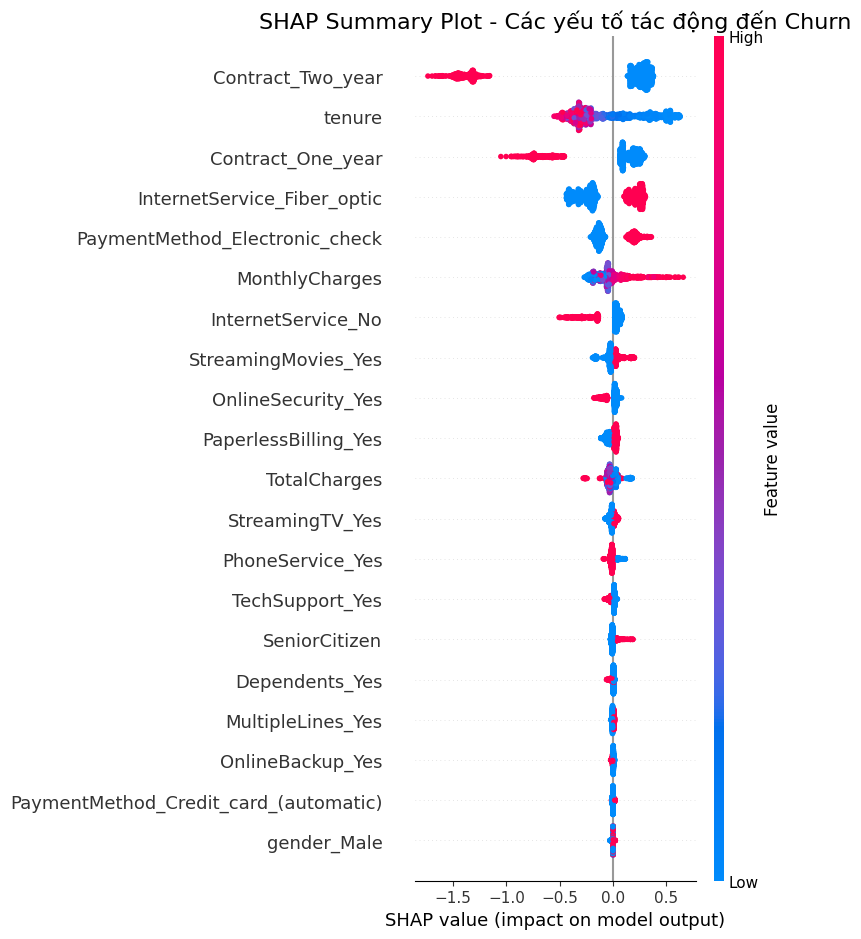


CÁCH ĐỌC BIỂU ĐỒ:
- Trục dọc: Các feature quan trọng nhất xếp từ trên xuống.
- Trục ngang: SHAP value. Nếu > 0 (bên phải), yếu tố đó ĐẨY mạnh khả năng KH rời mạng.
- Màu sắc: Màu ĐỎ là giá trị feature cao, màu XANH là giá trị thấp.
=> Ví dụ: TotalCharges màu ĐỎ (cước phí cao) nằm ở bên phải (SHAP > 0) -> Cước cao dễ gây rời mạng.


In [8]:
!pip install -q shap

import shap
import matplotlib.pyplot as plt

print("Đang tính toán giá trị SHAP (Quá trình này có thể mất 1-2 phút)...")

# Cần khởi tạo JS để vẽ biểu đồ SHAP đẹp trên Colab
shap.initjs()

# Khởi tạo TreeExplainer cho mô hình XGBoost
explainer = shap.TreeExplainer(best_xgb_model)

# Tính toán SHAP values trên tập Test
shap_values = explainer.shap_values(X_test_xgb)

# Vẽ biểu đồ Summary Plot
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot - Các yếu tố tác động đến Churn", fontsize=16)
shap.summary_plot(shap_values, X_test_xgb, show=False)
plt.tight_layout()
plt.show()

print("\nCÁCH ĐỌC BIỂU ĐỒ:")
print("- Trục dọc: Các feature quan trọng nhất xếp từ trên xuống.")
print("- Trục ngang: SHAP value. Nếu > 0 (bên phải), yếu tố đó ĐẨY mạnh khả năng KH rời mạng.")
print("- Màu sắc: Màu ĐỎ là giá trị feature cao, màu XANH là giá trị thấp.")
print("=> Ví dụ: TotalCharges màu ĐỎ (cước phí cao) nằm ở bên phải (SHAP > 0) -> Cước cao dễ gây rời mạng.")

# Phần 9: Fairness Analysis (Phân tích Thiên kiến & Công bằng)
Hệ thống AI không được phép phân biệt đối xử. Ta sẽ kiểm tra xem mô hình có sự chênh lệch (Bias) lớn nào trong việc dự đoán sai (False Positive Rate) hoặc bỏ sót (False Negative Rate) giữa các nhóm:
- **Giới tính:** Nam (gender_Male = 1) vs Nữ (gender_Male = 0).
- **Độ tuổi:** Người cao tuổi (SeniorCitizen = 1) vs Người trẻ (SeniorCitizen = 0).

In [9]:
import pandas as pd
from sklearn.metrics import confusion_matrix

print("=== KIỂM TRA THIÊN KIẾN (BIAS CHECK) ===\n")

# Gộp kết quả dự đoán và dữ liệu thực tế vào một DataFrame để dễ phân tích
df_fairness = X_test_xgb.copy()
df_fairness['Actual_Churn'] = y_test
df_fairness['Predicted_Churn'] = y_pred_best

def print_fairness_metrics(df, group_col, group_name_0, group_name_1):
    print(f"--- Phân tích theo {group_col} ---")
    for val, name in zip([0, 1], [group_name_0, group_name_1]):
        subset = df[df[group_col] == val]
        tn, fp, fn, tp = confusion_matrix(subset['Actual_Churn'], subset['Predicted_Churn']).ravel()

        recall = tp / (tp + fn) # Tỷ lệ bắt trúng KH rời mạng (Càng cao càng tốt)
        fpr = fp / (fp + tn)    # Tỷ lệ bắt nhầm KH không rời mạng (Càng thấp càng tốt)

        print(f"Nhóm {name}:")
        print(f"  + Recall (Bắt trúng): {recall*100:.1f}%")
        print(f"  + False Positive Rate (Báo động giả): {fpr*100:.1f}%\n")

# 1. Kiểm tra thiên kiến Giới tính (Do ta dùng drop_first=True nên cột chỉ còn gender_Male)
if 'gender_Male' in df_fairness.columns:
    print_fairness_metrics(df_fairness, 'gender_Male', 'Nữ', 'Nam')

# 2. Kiểm tra thiên kiến Độ tuổi
if 'SeniorCitizen' in df_fairness.columns:
    print_fairness_metrics(df_fairness, 'SeniorCitizen', 'Người trẻ', 'Người cao tuổi')

print("=> KẾT LUẬN: Nếu các chỉ số Recall và FPR chênh lệch quá 10% giữa hai nhóm, mô hình đang bị Bias và cần được cân bằng lại dữ liệu huấn luyện (Resampling hoặc Reweighting).")

=== KIỂM TRA THIÊN KIẾN (BIAS CHECK) ===

--- Phân tích theo gender_Male ---
Nhóm Nữ:
  + Recall (Bắt trúng): 80.7%
  + False Positive Rate (Báo động giả): 31.2%

Nhóm Nam:
  + Recall (Bắt trúng): 84.5%
  + False Positive Rate (Báo động giả): 30.6%

--- Phân tích theo SeniorCitizen ---
Nhóm Người trẻ:
  + Recall (Bắt trúng): 79.5%
  + False Positive Rate (Báo động giả): 27.2%

Nhóm Người cao tuổi:
  + Recall (Bắt trúng): 91.7%
  + False Positive Rate (Báo động giả): 55.1%

=> KẾT LUẬN: Nếu các chỉ số Recall và FPR chênh lệch quá 10% giữa hai nhóm, mô hình đang bị Bias và cần được cân bằng lại dữ liệu huấn luyện (Resampling hoặc Reweighting).


# Phần 10: Ethics Discussion (Đạo đức AI & Rủi ro Mô hình)

Khi đưa mô hình này vào thực tế, cần phải ghi nhận các rủi ro sau trong báo cáo hệ thống:

**1. Data Privacy (Bảo mật dữ liệu):**
* Dữ liệu viễn thông chứa thông tin tài chính (`TotalCharges`, `MonthlyCharges`) và thói quen sử dụng của người dùng.
* *Biện pháp:* Dữ liệu phải được ẩn danh hóa (Anonymized) hoàn toàn. Đó là lý do ta đã loại bỏ cột `customerID` ngay từ bước Preprocessing để tránh lộ thông tin định danh cá nhân (PII).

**2. Model Risk & Business Impact (Rủi ro Mô hình):**
* **Hậu quả của False Positive (Dự đoán rời nhưng thực tế không rời):** Gửi nhầm tin nhắn khuyến mãi giữ chân, gây lãng phí chi phí Marketing (Cost of retention).
* **Hậu quả của False Negative (Dự đoán không rời nhưng thực tế có rời):** Doanh nghiệp mất trắng khách hàng và doanh thu từ họ.
* *Quyết định Đạo đức/Kinh doanh:* Việc đánh mất một khách hàng tốn kém hơn nhiều so với việc gửi dư một SMS khuyến mãi. Do đó, mô hình này được chủ đích thiết kế (thông qua `scale_pos_weight`) để ưu tiên chỉ số **Recall** (chấp nhận hy sinh Accuracy/Precision) nhằm thà bắt nhầm còn hơn bỏ sót.